# Assignment 4  Master Notebook
**Transformers, Attention, SHAP & LIME**
| Section | Content |
|---|---|
| 1 | Install & Imports |
| 2 | Data Pipeline |
| 3 | BERT Fine-Tuning |
| 4 | Evaluation & Metrics |
| 5 | Attention Analysis |
| 6 | SHAP Explainability |
| 7 | LIME Explainability |
| 8 | SHAP vs LIME Comparison |
| 9 | Error Analysis |

## 1. Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn pandas shap lime bertviz --quiet
print('All packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.4 MB/s eta 0:00:00
All packages installed


In [2]:
import re, os, time, random, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : Tesla T4


---
## 2. Data Pipeline

In [3]:
# ── Constants ────────────────────────────────────────────────────────────────
MODEL_NAME      = 'bert-base-uncased'
MAX_LEN         = 128
BATCH_SIZE      = 32
TOTAL_SAMPLES   = 20000
SAMPLES_PER_CLASS = TOTAL_SAMPLES // 2
LABEL_MAP       = {0: 'Negative', 1: 'Positive'}
os.makedirs('data',  exist_ok=True)
os.makedirs('model', exist_ok=True)


In [4]:
# ── Load from HuggingFace ────────────────────────────────────────────────────
print('Loading Amazon Polarity dataset...')
raw_dataset = load_dataset('fancyzhx/amazon_polarity')
print(raw_dataset)

train_data = raw_dataset['train'].shuffle(seed=SEED)
neg_samples = [x for x in train_data if x['label'] == 0][:SAMPLES_PER_CLASS]
pos_samples = [x for x in train_data if x['label'] == 1][:SAMPLES_PER_CLASS]
all_samples = neg_samples + pos_samples
random.shuffle(all_samples)

df = pd.DataFrame(all_samples)
df['text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')
df = df[['text','label']].reset_index(drop=True)
print(f'Loaded {len(df)} samples | Label dist: {dict(df["label"].value_counts())}')

Loading Amazon Polarity dataset...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})
Loaded 20000 samples | Label dist: {0: np.int64(10000), 1: np.int64(10000)}


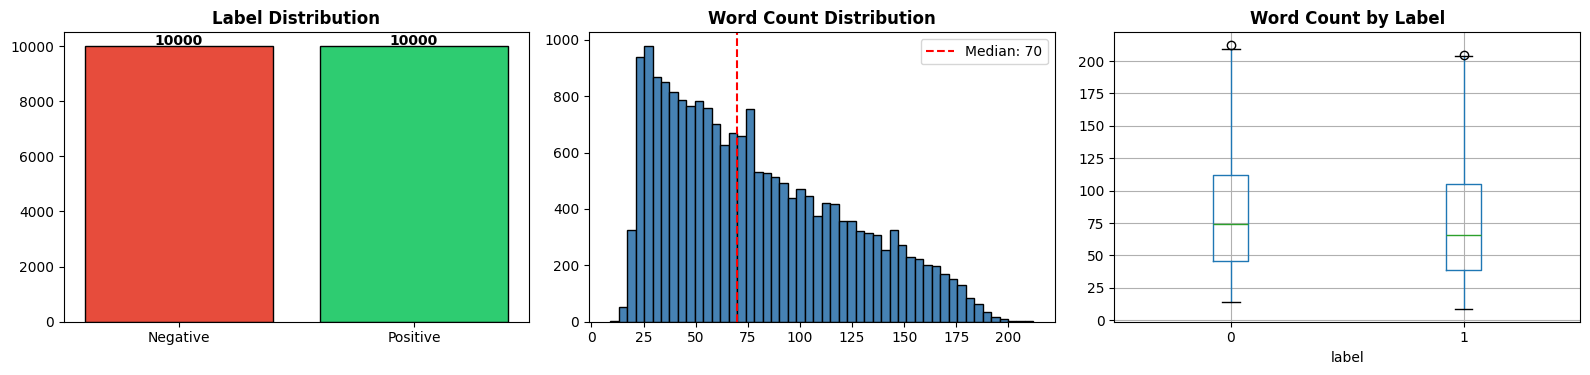

count    20000.00000
mean        78.58930
std         43.01634
min          9.00000
25%         42.00000
50%         70.00000
75%        109.00000
max        212.00000
Name: text_length, dtype: float64


In [5]:
# ── EDA plots ────────────────────────────────────────────────────────────────
df['text_length'] = df['text'].str.split().str.len()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['label'].map(LABEL_MAP).value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution', fontweight='bold')
for i,v in enumerate(counts.values): axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

axes[1].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(df['text_length'].median(), color='red', linestyle='--',
                label=f'Median: {df["text_length"].median():.0f}')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].legend()

df.boxplot(column='text_length', by='label', ax=axes[2])
axes[2].set_title('Word Count by Label', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.show()
print(df['text_length'].describe())

In [6]:
# ── Text Cleaning ────────────────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)
before = len(df)
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)
print(f'Rows after cleaning: {len(df)} (removed {before - len(df)})')

Rows after cleaning: 19999 (removed 1)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token coverage at MAX_LEN=128: 79.0%


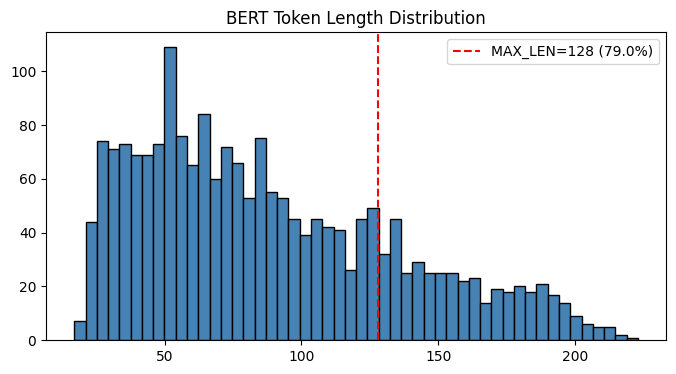

In [7]:
# ── Tokenizer & token-length coverage ───────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

sample_tok_lens = [
    len(tokenizer(t, truncation=False)['input_ids'])
    for t in df['text_clean'].sample(2000, random_state=SEED)
]
coverage = sum(l <= MAX_LEN for l in sample_tok_lens) / len(sample_tok_lens) * 100
print(f'Token coverage at MAX_LEN={MAX_LEN}: {coverage:.1f}%')

plt.figure(figsize=(8,4))
plt.hist(sample_tok_lens, bins=50, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN} ({coverage:.1f}%)')
plt.title('BERT Token Length Distribution'); plt.legend()
plt.show()

In [8]:
# ── Train / Val / Test split ─────────────────────────────────────────────────
texts  = df['text_clean'].tolist()
labels = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

for name, (tx, ty) in [('train',(X_train,y_train)),('val',(X_val,y_val)),('test',(X_test,y_test))]:
    pd.DataFrame({'text':tx,'label':ty}).to_csv(f'data/{name}.csv', index=False)
print('Splits saved to data/')

Train: 13999 | Val: 3000 | Test: 3000
Splits saved to data/


---
## 3. BERT Fine-Tuning

In [9]:
class AmazonDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(AmazonDataset(X_train,y_train,tokenizer,MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(AmazonDataset(X_val,  y_val,  tokenizer,MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(AmazonDataset(X_test, y_test, tokenizer,MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches — Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)}')

Batches — Train:438 Val:94 Test:94


In [10]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, output_attentions=True).to(DEVICE)

EPOCHS = 3; LR = 2e-5; WARMUP_RATIO = 0.1
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

no_decay = ['bias','LayerNorm.weight']
optimizer = AdamW([
    {'params':[p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay':0.01},
    {'params':[p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay':0.0}
], lr=LR)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Model loaded | Total steps: {total_steps} | Warmup: {warmup_steps}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded | Total steps: 1314 | Warmup: 131


In [11]:
def run_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask, labels=labs)
            loss = out.loss
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item()
            preds = torch.argmax(out.logits, dim=1).cpu().numpy()
            all_preds.extend(preds); all_labels.extend(labs.cpu().numpy())
            if training and (step+1) % 50 == 0:
                print(f'  step {step+1}/{len(loader)} loss={total_loss/(step+1):.4f} acc={accuracy_score(all_labels,all_preds):.4f}')
    metrics = dict(
        loss = total_loss/len(loader),
        acc  = accuracy_score(all_labels, all_preds),
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    )
    return metrics, all_preds, all_labels

history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
best_f1, patience, patience_ctr = 0, 2, 0

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    print(f'\n{'='*55}\nEPOCH {epoch}/{EPOCHS}\n{'='*55}')
    tr, _, _  = run_epoch(model, train_loader, optimizer, scheduler)
    vl, _, _  = run_epoch(model, val_loader)
    print(f'Train loss={tr["loss"]:.4f} acc={tr["acc"]:.4f}')
    print(f'Val   loss={vl["loss"]:.4f} acc={vl["acc"]:.4f} f1={vl["f1"]:.4f} [{(time.time()-t0)/60:.1f}m]')
    history['train_loss'].append(tr['loss']); history['val_loss'].append(vl['loss'])
    history['train_acc'].append(tr['acc']);   history['val_acc'].append(vl['acc'])
    if vl['f1'] > best_f1:
        best_f1 = vl['f1']; patience_ctr = 0
        model.save_pretrained('model/best_bert'); tokenizer.save_pretrained('model/best_bert')
        print(f'   Best model saved (f1={best_f1:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= patience: print('Early stop.'); break

print('\nTraining complete.')


EPOCH 1/3
  step 50/438 loss=0.6853 acc=0.5637
  step 100/438 loss=0.5642 acc=0.6981
  step 150/438 loss=0.4607 acc=0.7706
  step 200/438 loss=0.3988 acc=0.8084
  step 250/438 loss=0.3565 acc=0.8333
  step 300/438 loss=0.3314 acc=0.8490
  step 350/438 loss=0.3111 acc=0.8603
  step 400/438 loss=0.2967 acc=0.8685
Train loss=0.2883 acc=0.8731
Val   loss=0.2101 acc=0.9207 f1=0.9206 [5.0m]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Best model saved (f1=0.9206)

EPOCH 2/3
  step 50/438 loss=0.1311 acc=0.9544
  step 100/438 loss=0.1214 acc=0.9572
  step 150/438 loss=0.1167 acc=0.9590
  step 200/438 loss=0.1198 acc=0.9586
  step 250/438 loss=0.1190 acc=0.9594
  step 300/438 loss=0.1157 acc=0.9595
  step 350/438 loss=0.1178 acc=0.9599
  step 400/438 loss=0.1185 acc=0.9598
Train loss=0.1173 acc=0.9604
Val   loss=0.2258 acc=0.9287 f1=0.9287 [5.0m]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Best model saved (f1=0.9287)

EPOCH 3/3
  step 50/438 loss=0.0572 acc=0.9819
  step 100/438 loss=0.0526 acc=0.9850
  step 150/438 loss=0.0550 acc=0.9850
  step 200/438 loss=0.0565 acc=0.9848
  step 250/438 loss=0.0590 acc=0.9845
  step 300/438 loss=0.0583 acc=0.9846
  step 350/438 loss=0.0586 acc=0.9846
  step 400/438 loss=0.0578 acc=0.9848
Train loss=0.0575 acc=0.9848
Val   loss=0.2801 acc=0.9307 f1=0.9307 [5.0m]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Best model saved (f1=0.9307)

Training complete.


---
## 4. Evaluation & Metrics

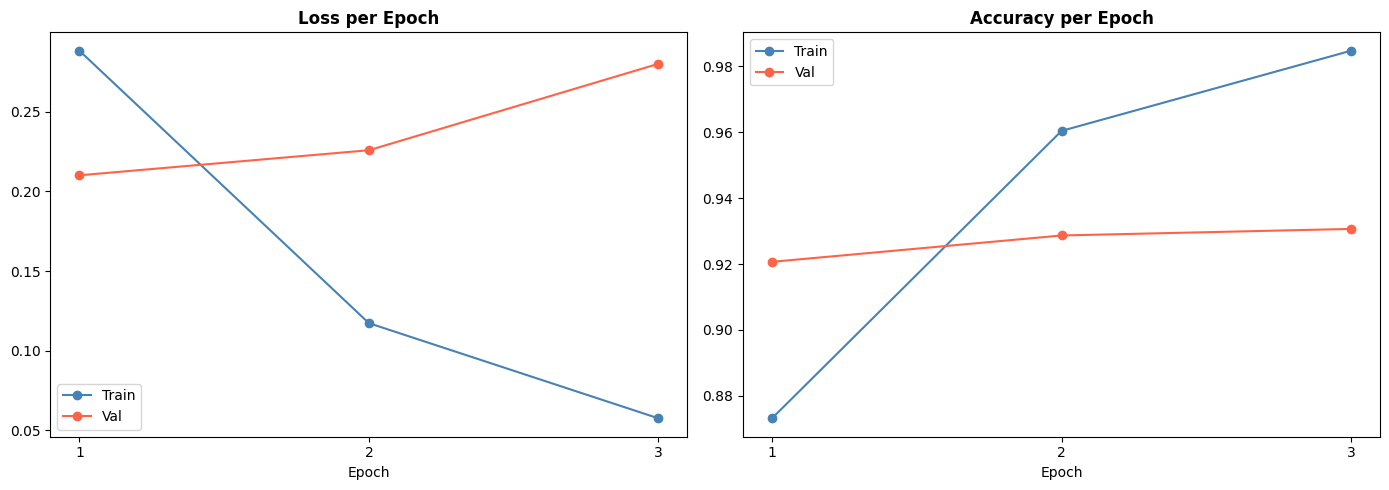

In [12]:
# Training curves
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, metric, title in zip(axes, ['loss','acc'], ['Loss','Accuracy']):
    ax.plot(ep, history[f'train_{metric}'], 'o-', label='Train', color='steelblue')
    ax.plot(ep, history[f'val_{metric}'],   'o-', label='Val',   color='tomato')
    ax.set_title(f'{title} per Epoch', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.set_xticks(list(ep))
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

        TEST SET RESULTS
  loss    : 0.2145
  acc     : 0.9463
  prec    : 0.9463
  rec     : 0.9463
  f1      : 0.9463

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95      1500
    Positive       0.95      0.95      0.95      1500

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



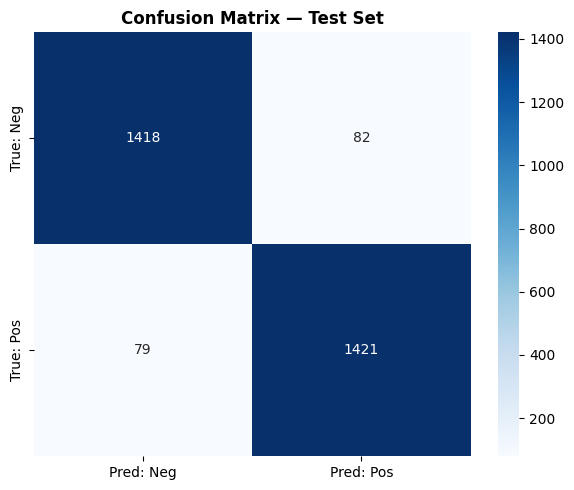

In [13]:
# Load best model and evaluate on test set
best_model = BertForSequenceClassification.from_pretrained('model/best_bert', output_attentions=True).to(DEVICE)
test_metrics, test_preds, test_labels = run_epoch(best_model, test_loader)

print('='*50)
print('        TEST SET RESULTS')
print('='*50)
for k,v in test_metrics.items(): print(f'  {k:8s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=['Negative','Positive']))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Neg','Pred: Pos'],
            yticklabels=['True: Neg','True: Pos'])
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Save test predictions for SHAP/LIME/Error Analysis
test_df = pd.read_csv('data/test.csv')
test_df['pred_label'] = test_preds
test_df['correct']    = (test_df['label'] == test_df['pred_label'])
test_df['pred_name']  = test_df['pred_label'].map(LABEL_MAP)
test_df['true_name']  = test_df['label'].map(LABEL_MAP)
test_df.to_csv('data/test_with_preds.csv', index=False)
print(f'Saved test_with_preds.csv | Correct: {test_df["correct"].sum()}/{len(test_df)}')

Saved test_with_preds.csv | Correct: 2839/3000


---
## 5. Attention Analysis

In [15]:
def get_attention_for_text(text, model, tokenizer, max_len=128):
    """Returns tokens and attention tensors for a single text."""
    model.eval()
    enc = tokenizer(text, max_length=max_len, truncation=True,
                    padding='max_length', return_tensors='pt')
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    # outputs.attentions: tuple of (1, num_heads, seq_len, seq_len) per layer
    attentions = [a.squeeze(0).cpu().numpy() for a in outputs.attentions]
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    # Trim to real tokens (exclude padding)
    real_len = attention_mask[0].sum().item()
    tokens   = tokens[:real_len]
    attentions = [a[:, :real_len, :real_len] for a in attentions]
    return tokens, attentions

print('Attention extraction function ready.')

Attention extraction function ready.


In [16]:
def plot_attention_heatmap(tokens, attention_matrix, layer, head, title_suffix=''):
    """Plot a single attention head heatmap."""
    fig, ax = plt.subplots(figsize=(max(8, len(tokens)*0.5), max(6, len(tokens)*0.4)))
    im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Attention Heatmap — Layer {layer+1}, Head {head+1}\n{title_suffix}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Key tokens (attended TO)')
    ax.set_ylabel('Query tokens (attending FROM)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fname = f'plots/attention_L{layer+1}_H{head+1}.png'
    plt.show()
    return fname

In [17]:
# Pick two samples — one positive, one negative
sample_pos = test_df[test_df['label']==1]['text'].iloc[0]
sample_neg = test_df[test_df['label']==0]['text'].iloc[0]

print('POSITIVE sample:')
print(sample_pos[:200])
print('\nNEGATIVE sample:')
print(sample_neg[:200])

POSITIVE sample:
al is a genius but we knew that already they just get better and better i love the whole album you rule al please come here and do a concert again

NEGATIVE sample:
title misleading not what you think i bought this book thinking it would help me in my new venture of antique collecting while the authors are very well qualified in this subject i feel as though it w


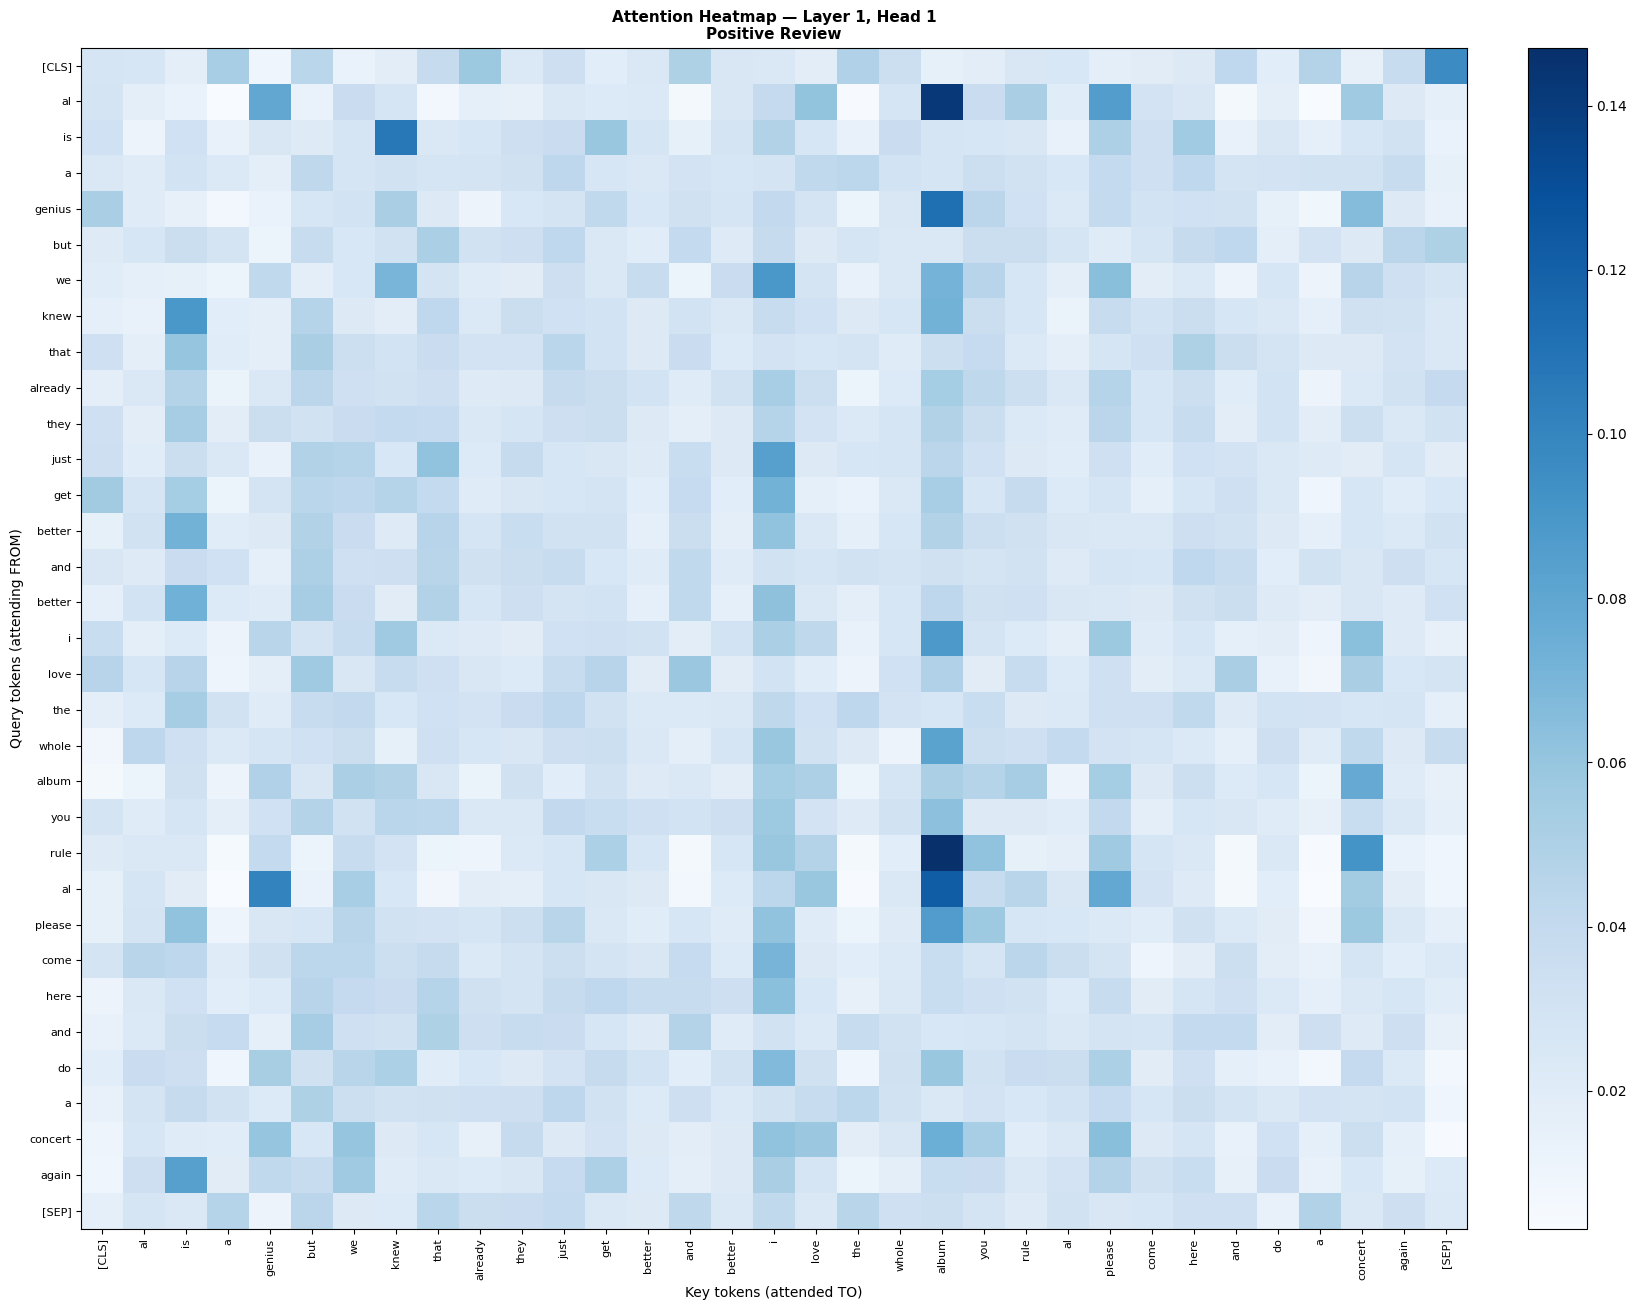

Tokens: ['[CLS]', 'al', 'is', 'a', 'genius', 'but', 'we', 'knew', 'that', 'already', 'they', 'just', 'get', 'better', 'and', 'better', 'i', 'love', 'the', 'whole', 'album', 'you', 'rule', 'al', 'please', 'come', 'here', 'and', 'do', 'a', 'concert', 'again', '[SEP]']


In [18]:
# ── Heatmap 1: Layer 1, Head 1 — Positive review ────────────────────────────
tokens_pos, attns_pos = get_attention_for_text(sample_pos, best_model, tokenizer)
plot_attention_heatmap(tokens_pos, attns_pos[0][0], layer=0, head=0,
                       title_suffix='Positive Review')
print(f'Tokens: {tokens_pos}')

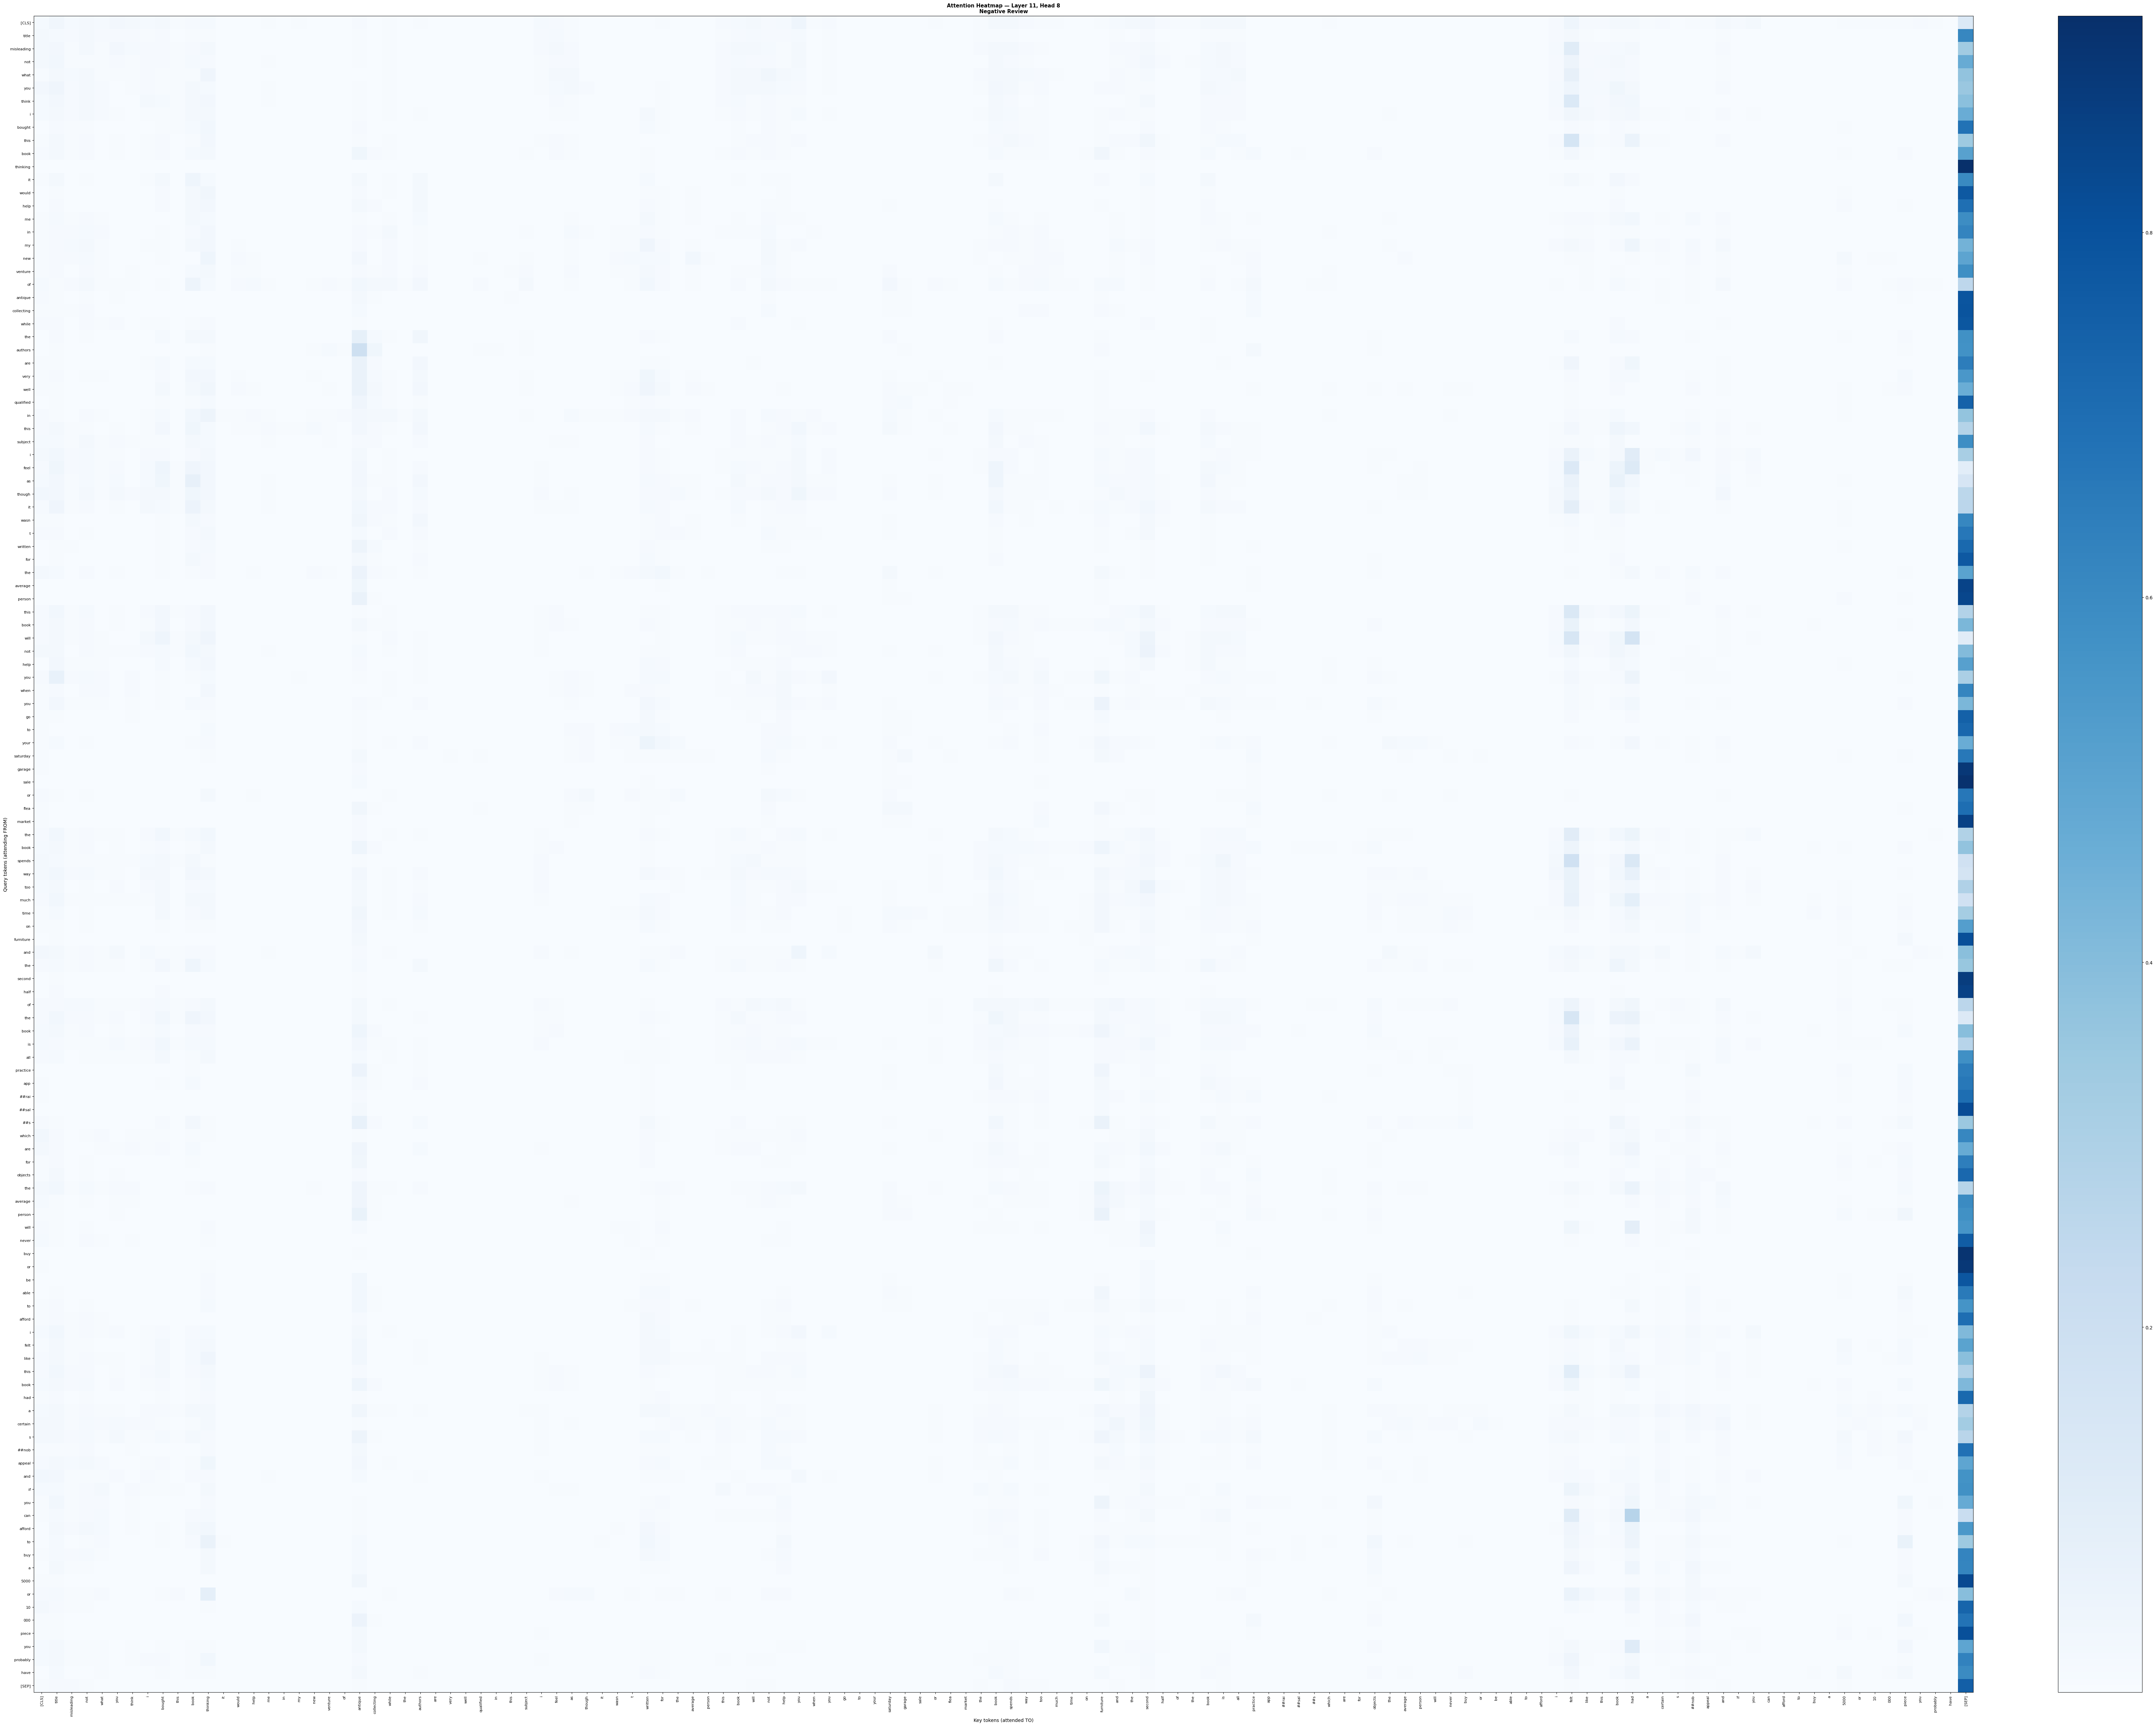

Tokens: ['[CLS]', 'title', 'misleading', 'not', 'what', 'you', 'think', 'i', 'bought', 'this', 'book', 'thinking', 'it', 'would', 'help', 'me', 'in', 'my', 'new', 'venture', 'of', 'antique', 'collecting', 'while', 'the', 'authors', 'are', 'very', 'well', 'qualified', 'in', 'this', 'subject', 'i', 'feel', 'as', 'though', 'it', 'wasn', 't', 'written', 'for', 'the', 'average', 'person', 'this', 'book', 'will', 'not', 'help', 'you', 'when', 'you', 'go', 'to', 'your', 'saturday', 'garage', 'sale', 'or', 'flea', 'market', 'the', 'book', 'spends', 'way', 'too', 'much', 'time', 'on', 'furniture', 'and', 'the', 'second', 'half', 'of', 'the', 'book', 'is', 'all', 'practice', 'app', '##rai', '##sal', '##s', 'which', 'are', 'for', 'objects', 'the', 'average', 'person', 'will', 'never', 'buy', 'or', 'be', 'able', 'to', 'afford', 'i', 'felt', 'like', 'this', 'book', 'had', 'a', 'certain', 's', '##nob', 'appeal', 'and', 'if', 'you', 'can', 'afford', 'to', 'buy', 'a', '5000', 'or', '10', '000', 'piece

In [19]:
# ── Heatmap 2: Layer 11, Head 8 — Negative review ───────────────────────────
# Layer 11 (last) captures high-level semantic attention
tokens_neg, attns_neg = get_attention_for_text(sample_neg, best_model, tokenizer)
plot_attention_heatmap(tokens_neg, attns_neg[10][7], layer=10, head=7,
                       title_suffix='Negative Review')
print(f'Tokens: {tokens_neg}')

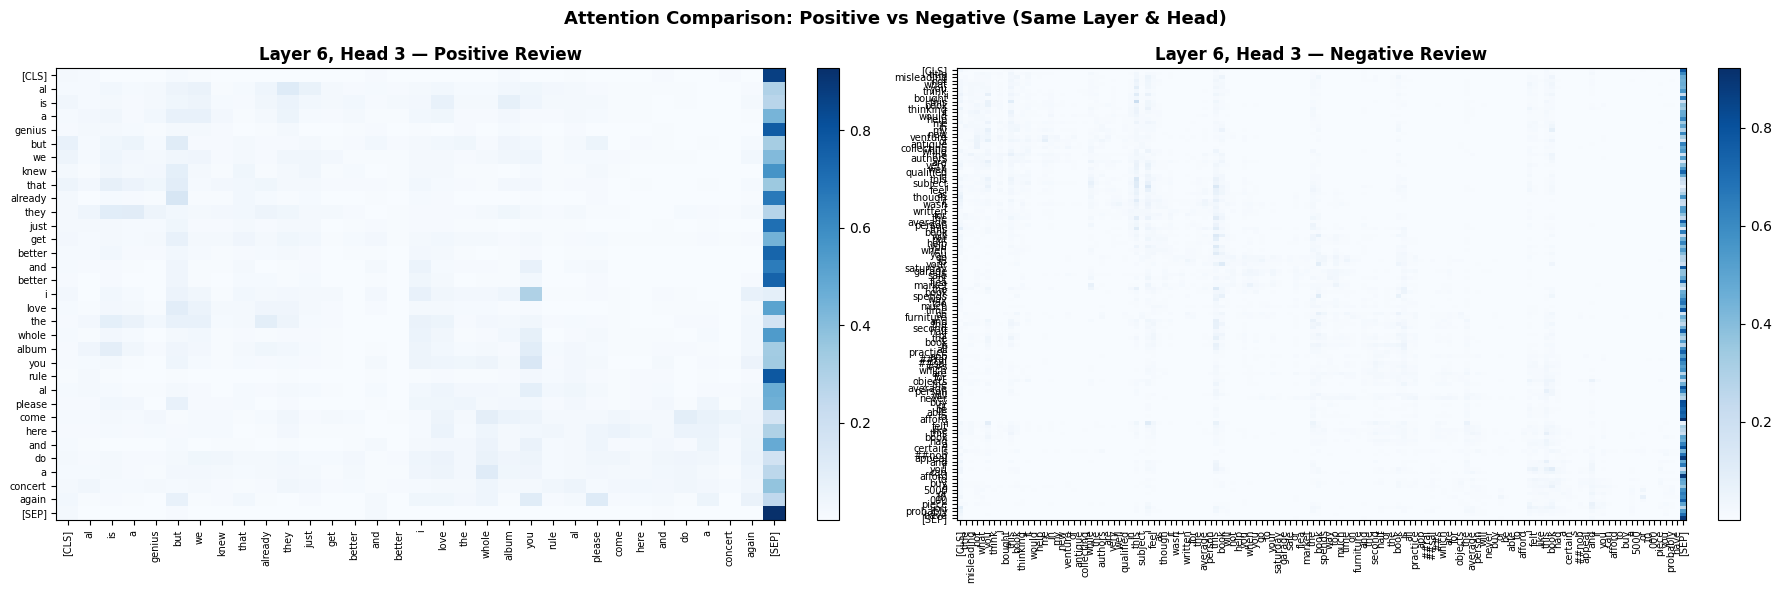


Discussion: Compare which tokens receive high attention in positive vs negative reviews.


In [20]:
# ── Heatmap 3: Layer 6, Head 3 — compare both ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, tokens, attns, label in [
    (axes[0], tokens_pos, attns_pos, 'Positive'),
    (axes[1], tokens_neg, attns_neg, 'Negative')
]:
    mat = attns[5][2]  # Layer 6, Head 3
    im  = ax.imshow(mat, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Layer 6, Head 3 — {label} Review', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Attention Comparison: Positive vs Negative (Same Layer & Head)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nDiscussion: Compare which tokens receive high attention in positive vs negative reviews.')

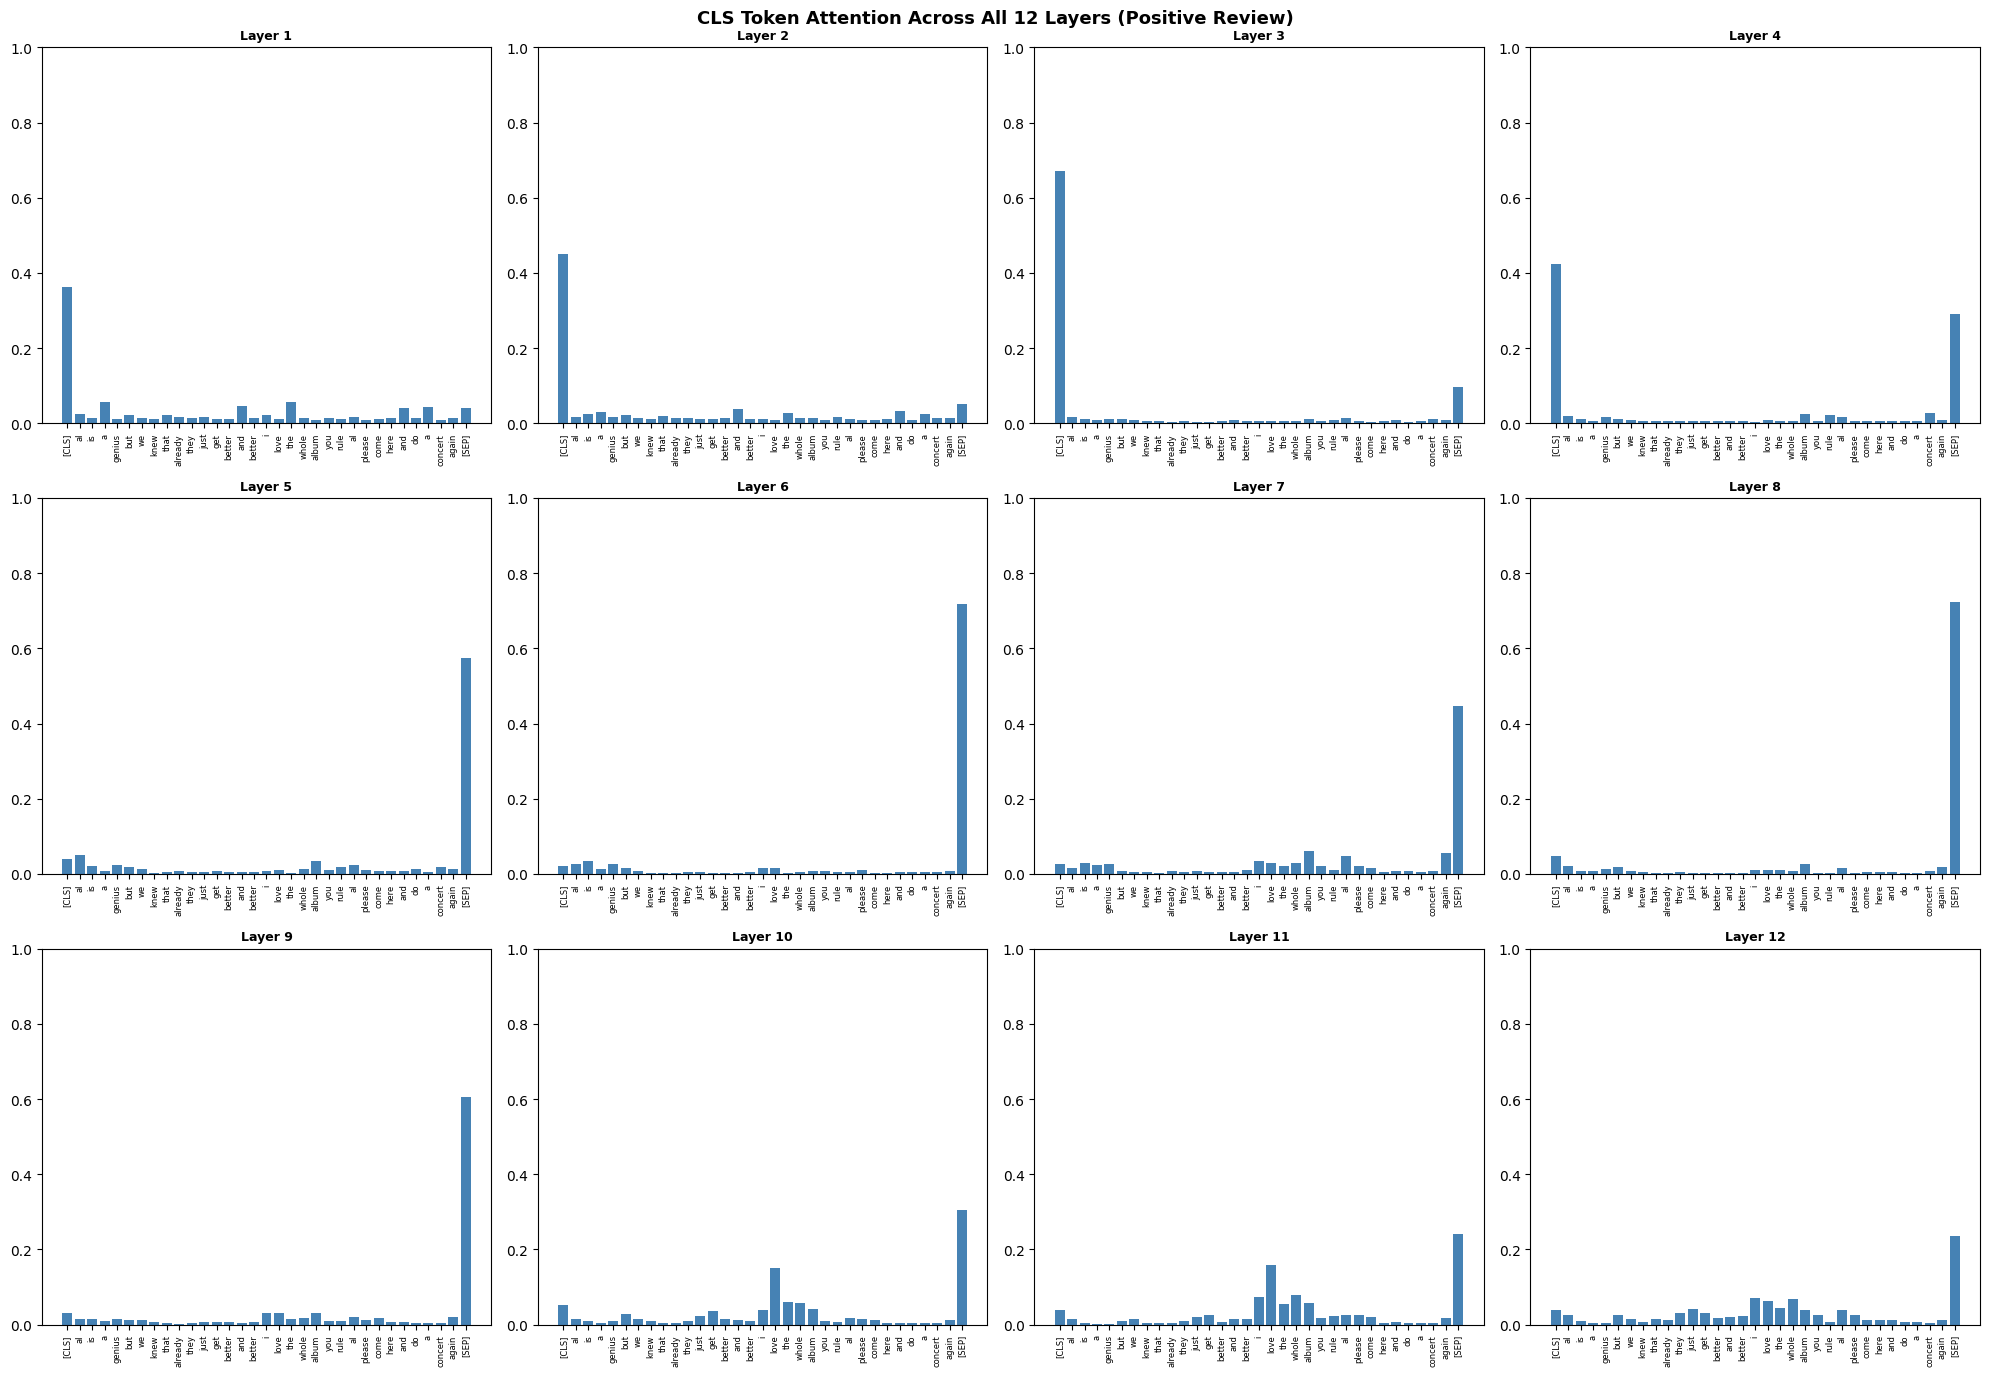

In [21]:
# ── CLS token attention across all layers ────────────────────────────────────
# CLS token aggregates sentence-level info — useful for classification
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for layer_idx in range(12):
    # Average across all heads for this layer
    cls_attn = attns_pos[layer_idx].mean(axis=0)[0]  # CLS row, averaged over heads
    axes[layer_idx].bar(range(len(tokens_pos)), cls_attn, color='steelblue')
    axes[layer_idx].set_xticks(range(len(tokens_pos)))
    axes[layer_idx].set_xticklabels(tokens_pos, rotation=90, fontsize=6)
    axes[layer_idx].set_title(f'Layer {layer_idx+1}', fontsize=9, fontweight='bold')
    axes[layer_idx].set_ylim(0, 1)
plt.suptitle('CLS Token Attention Across All 12 Layers (Positive Review)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. SHAP Explainability

In [22]:
import shap

# Define prediction function for SHAP
def predict_proba(texts):
    best_model.eval()
    all_probs = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        enc = tokenizer(
            batch, max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        with torch.no_grad():
            logits = best_model(
                input_ids=enc['input_ids'].to(DEVICE),
                attention_mask=enc['attention_mask'].to(DEVICE)
            ).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

print('predict_proba function ready.')

predict_proba function ready.


In [23]:
# Build SHAP explainer using a small background set
# Use 50 background samples for efficiency on free Colab
background_texts = X_train[:50]
explainer_shap   = shap.Explainer(predict_proba, masker=shap.maskers.Text(tokenizer))
print('SHAP explainer built.')

SHAP explainer built.


In [24]:
# Explain 20 test samples with SHAP
# Sample 10 positive + 10 negative for balanced coverage
shap_pos_texts = test_df[test_df['label']==1]['text'].head(10).tolist()
shap_neg_texts = test_df[test_df['label']==0]['text'].head(10).tolist()
shap_texts     = shap_pos_texts + shap_neg_texts
shap_true_labs = [1]*10 + [0]*10

print(f'Running SHAP on {len(shap_texts)} samples...')
shap_values = explainer_shap(shap_texts)
print('SHAP values computed.')

Running SHAP on 20 samples...


PartitionExplainer explainer: 21it [01:21,  4.30s/it]

SHAP values computed.


In [25]:
# SHAP text plot for first 4 samples
for i in range(4):
    print(f'\n--- SHAP Explanation {i+1} (True: {LABEL_MAP[shap_true_labs[i]]}) ---')
    shap.plots.text(shap_values[i], display=True)


--- SHAP Explanation 1 (True: Positive) ---



--- SHAP Explanation 2 (True: Positive) ---



--- SHAP Explanation 3 (True: Positive) ---



--- SHAP Explanation 4 (True: Positive) ---


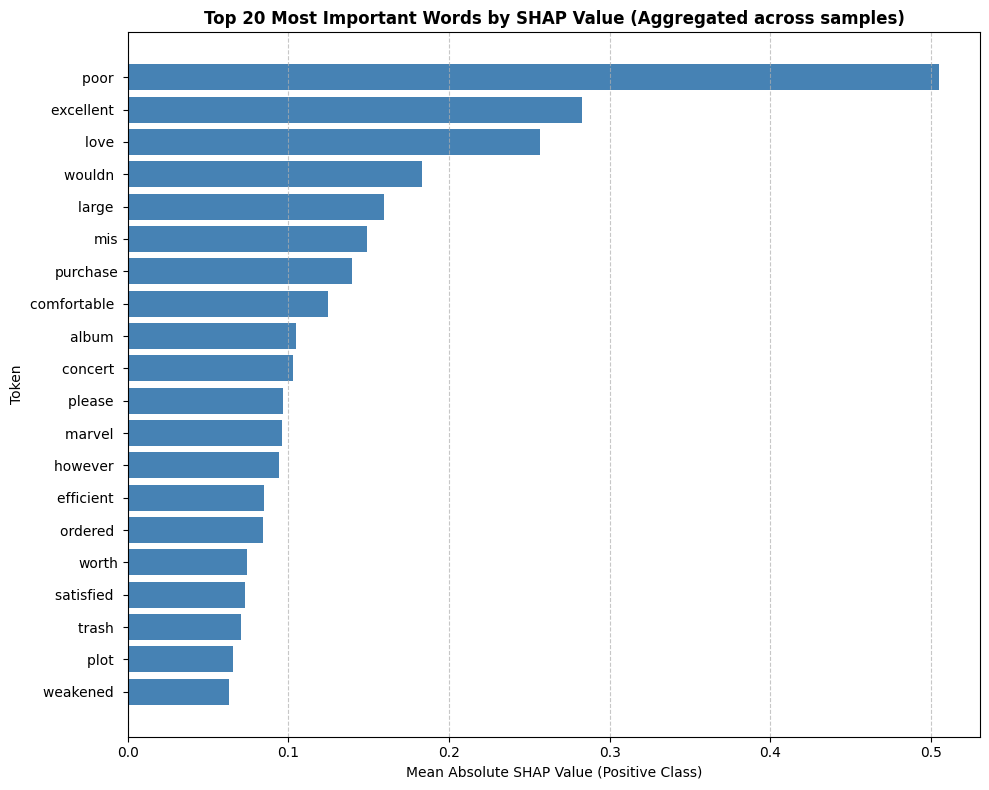

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# shap_values is a shap.Explanation object. It contains explanations for multiple samples.
# shap_values[i].data provides the tokens (words) for the i-th sample.
# shap_values[i].values provides the SHAP values (num_tokens_in_sample, num_classes) for the i-th sample.

word_shap_scores = Counter()
word_occurrences = Counter()

# Iterate through each sample's explanation within the shap_values object
for i in range(len(shap_values)):
    # Get tokens and SHAP values for the current sample
    single_sample_tokens = shap_values[i].data.tolist()
    single_sample_shap_values = shap_values[i].values

    # We are interested in the positive class (index 1) and absolute values
    # abs_shap_values_for_sample is a 1D numpy array (num_tokens_in_sample,)
    abs_shap_values_for_sample = np.abs(single_sample_shap_values[:, 1])

    # Aggregate SHAP values for each token
    for token, shap_val in zip(single_sample_tokens, abs_shap_values_for_sample):
        # Filter out special tokens ('[CLS]', '[SEP]', '[PAD]') and subword tokens ('##') for clearer visualization
        if token not in ['[CLS]', '[SEP]', '[PAD]', ''] and not token.startswith("##"):
            word_shap_scores[token] += shap_val
            word_occurrences[token] += 1

# Calculate the average absolute SHAP value for each word
mean_abs_shap_values = {word: word_shap_scores[word] / word_occurrences[word]
                        for word in word_shap_scores if word_occurrences[word] > 0}

# Sort words by their mean absolute SHAP value in descending order
sorted_words_and_values = sorted(mean_abs_shap_values.items(), key=lambda item: item[1], reverse=True)

# Select the top N words (using max_display=20 from the original request)
n = 20
top_words_for_plot = [word for word, _ in sorted_words_and_values[:n]]
top_values_for_plot = [value for _, value in sorted_words_and_values[:n]]

# Create the bar plot using matplotlib
plt.figure(figsize=(10, 8))
# Plot in reverse order so the highest value is at the top of the bar chart
plt.barh(top_words_for_plot[::-1], top_values_for_plot[::-1], color='steelblue')
plt.xlabel('Mean Absolute SHAP Value (Positive Class)')
plt.ylabel('Token')
plt.title(f'Top {n} Most Important Words by SHAP Value (Aggregated across samples)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# Save SHAP runtime for comparison
import time as _time
t_shap_start = _time.time()
_ = explainer_shap(shap_texts[:5])   # time 5 samples
shap_runtime_per_sample = (_time.time() - t_shap_start) / 5
print(f'SHAP avg runtime per sample: {shap_runtime_per_sample:.2f}s')

PartitionExplainer explainer: 6it [00:20,  6.76s/it]

SHAP avg runtime per sample: 4.06s


---
## 7. LIME Explainability

In [29]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(
    class_names=['Negative','Positive'],
    random_state=SEED
)
print('LIME explainer ready.')

LIME explainer ready.


In [30]:
# LIME explanation function
def lime_explain(text, num_features=15, num_samples=300):
    return lime_explainer.explain_instance(
        text,
        predict_proba,
        num_features=num_features,
        num_samples=num_samples,
        labels=[0, 1]
    )

# Explain 20 samples (same set as SHAP for fair comparison)
lime_texts    = shap_texts
lime_true_labs = shap_true_labs
lime_explanations = []

print(f'Running LIME on {len(lime_texts)} samples...')
for i, text in enumerate(lime_texts):
    exp = lime_explain(text)
    lime_explanations.append(exp)
    if (i+1) % 5 == 0:
        print(f'  {i+1}/{len(lime_texts)} done')
print('LIME explanations complete.')

Running LIME on 20 samples...
  5/20 done
  10/20 done
  15/20 done
  20/20 done
LIME explanations complete.



--- LIME Explanation 1 (True: Positive) ---


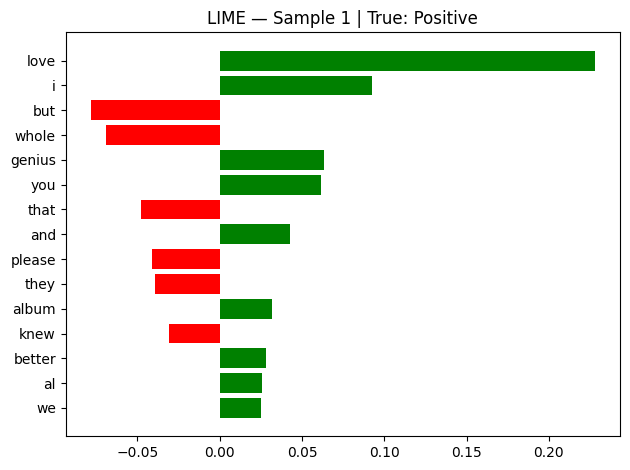


--- LIME Explanation 2 (True: Positive) ---


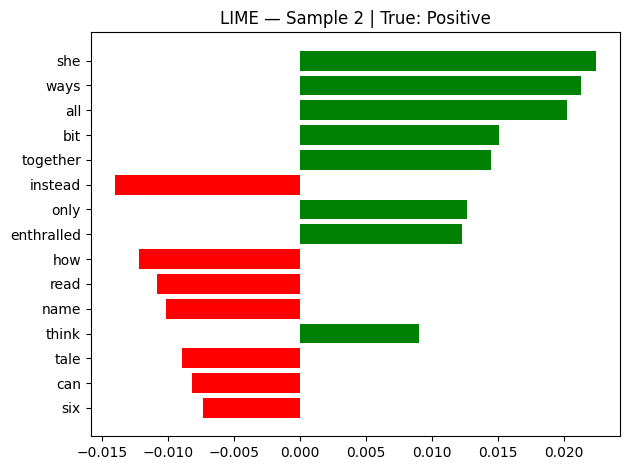


--- LIME Explanation 3 (True: Positive) ---


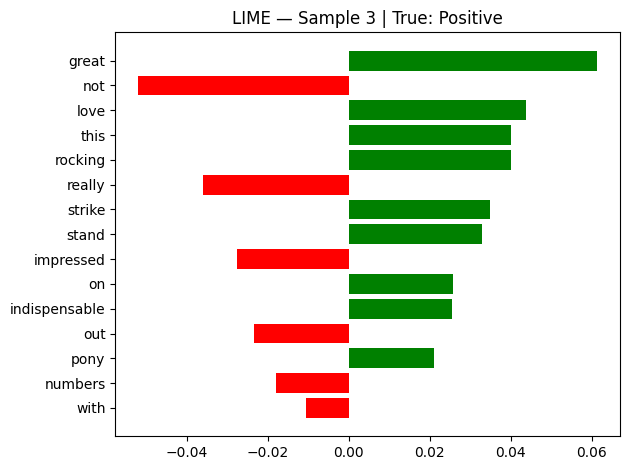


--- LIME Explanation 4 (True: Positive) ---


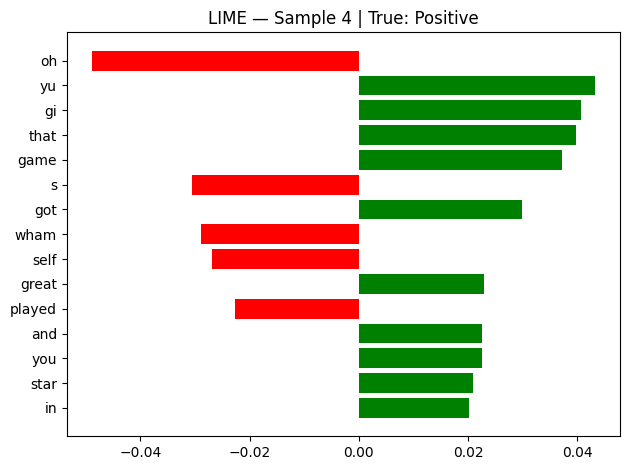

In [31]:
# Plot first 4 LIME explanations
for i in range(4):
    print(f'\n--- LIME Explanation {i+1} (True: {LABEL_MAP[lime_true_labs[i]]}) ---')
    fig = lime_explanations[i].as_pyplot_figure(label=lime_true_labs[i])
    plt.title(f'LIME — Sample {i+1} | True: {LABEL_MAP[lime_true_labs[i]]}')
    plt.tight_layout()
    plt.show()

In [32]:
# LIME runtime per sample
t_lime_start = _time.time()
_ = lime_explain(lime_texts[0])
lime_runtime_per_sample = _time.time() - t_lime_start
print(f'LIME avg runtime per sample: {lime_runtime_per_sample:.2f}s')

LIME avg runtime per sample: 2.20s


---
## 8. SHAP vs LIME Comparison

In [33]:
# ── Top-word overlap (Faithfulness proxy) ───────────────────────────────────
def get_shap_top_words(shap_val_obj, n=5):
    """Get top-n words by absolute SHAP value."""
    data   = shap_val_obj.data
    values = shap_val_obj.values
    if isinstance(data, np.ndarray): tokens = list(data)
    else: tokens = list(data)
    if len(values.shape) > 1: vals = values[:, 1]  # Positive class
    else: vals = values
    pairs = sorted(zip(tokens, np.abs(vals)), key=lambda x: x[1], reverse=True)
    return [w for w, _ in pairs[:n]]

def get_lime_top_words(lime_exp, label=1, n=5):
    """Get top-n words by absolute LIME weight."""
    pairs = lime_exp.as_list(label=label)
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    return [w for w, _ in pairs[:n]]

overlaps = []
for i in range(min(20, len(shap_values))):
    sw = set(get_shap_top_words(shap_values[i]))
    lw = set(get_lime_top_words(lime_explanations[i], label=lime_true_labs[i]))
    overlap = len(sw & lw) / len(sw | lw) if (sw | lw) else 0
    overlaps.append(overlap)

print(f'Mean top-5 word overlap (Jaccard): {np.mean(overlaps):.3f}')
print(f'Per-sample overlaps: {[round(o,2) for o in overlaps]}')

Mean top-5 word overlap (Jaccard): 0.000
Per-sample overlaps: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [34]:
# ── Stability: run LIME twice, measure consistency ───────────────────────────
lime_run1 = lime_explain(lime_texts[0])
lime_run2 = lime_explain(lime_texts[0])

words1 = dict(lime_run1.as_list(label=1))
words2 = dict(lime_run2.as_list(label=1))
common = set(words1) & set(words2)
if common:
    w1 = np.array([words1[w] for w in common])
    w2 = np.array([words2[w] for w in common])
    corr = np.corrcoef(w1, w2)[0, 1]
    print(f'LIME stability (weight correlation, 2 runs): {corr:.4f}')
else:
    print('No common words between LIME runs.')

# SHAP is deterministic — stability = 1.0
print('SHAP stability: 1.0 (deterministic given same model)')

LIME stability (weight correlation, 2 runs): 0.8174
SHAP stability: 1.0 (deterministic given same model)


     Criterion                      SHAP                           LIME
  Faithfulness High (Shapley guarantees) Moderate (local linear approx)
     Stability       1.0 (deterministic)              0.82 (stochastic)
Runtime/sample                     4.06s                          2.20s
         Scope            Global + local                     Local only
   Granularity               Token-level                     Word-level


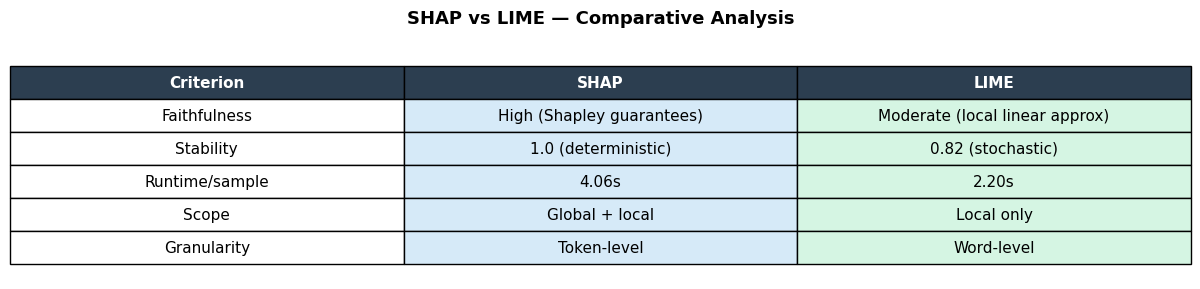

In [35]:
# ── Comparison Summary Table ─────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Criterion'   : ['Faithfulness','Stability','Runtime/sample','Scope','Granularity'],
    'SHAP'        : [
        'High (Shapley guarantees)',
        '1.0 (deterministic)',
        f'{shap_runtime_per_sample:.2f}s',
        'Global + local',
        'Token-level'
    ],
    'LIME'        : [
        'Moderate (local linear approx)',
        f'{corr:.2f} (stochastic)',
        f'{lime_runtime_per_sample:.2f}s',
        'Local only',
        'Word-level'
    ]
})

print(comparison.to_string(index=False))

# Plot as styled table
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tbl = ax.table(cellText=comparison.values, colLabels=comparison.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 1: cell.set_facecolor('#d6eaf8')
    elif c == 2: cell.set_facecolor('#d5f5e3')
plt.title('SHAP vs LIME — Comparative Analysis', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

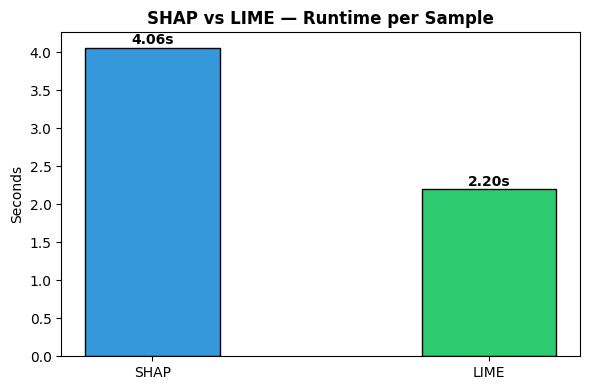

In [36]:
# Runtime bar chart
fig, ax = plt.subplots(figsize=(6,4))
methods  = ['SHAP', 'LIME']
runtimes = [shap_runtime_per_sample, lime_runtime_per_sample]
bars = ax.bar(methods, runtimes, color=['#3498db','#2ecc71'], edgecolor='black', width=0.4)
for bar, val in zip(bars, runtimes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}s', ha='center', fontweight='bold')
ax.set_title('SHAP vs LIME — Runtime per Sample', fontweight='bold')
ax.set_ylabel('Seconds')
plt.tight_layout()
plt.show()

---
## 9. Error Analysis

In [37]:
# Misclassified samples
errors = test_df[~test_df['correct']].reset_index(drop=True)
print(f'Total misclassified: {len(errors)} / {len(test_df)}')
print(f'Error rate: {len(errors)/len(test_df)*100:.2f}%')
print(f'\nError breakdown:')
print(errors.groupby(['true_name','pred_name']).size().reset_index(name='count'))

Total misclassified: 161 / 3000
Error rate: 5.37%

Error breakdown:
  true_name pred_name  count
0  Negative  Positive     82
1  Positive  Negative     79


Inspecting misclassified samples with LIME...


Error 1:
  True : Negative
  Pred : Positive (conf: 0.995)
  Text : not the one you should get depeche mode is a really great band but catching up with depeche mode is not the greatest hits collection to get if you want to hear the best from their early career the ban...


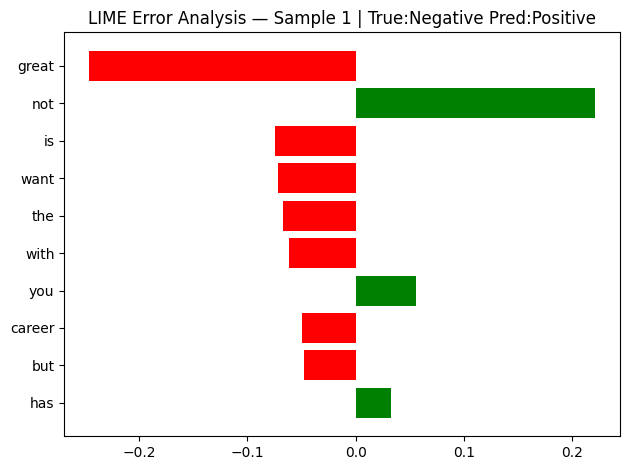


Error 2:
  True : Negative
  Pred : Positive (conf: 0.672)
  Text : acutally good idea for a book author creative yet not talented too awkward for child learning good illustrations but umm actually my daughter said it was stupid...


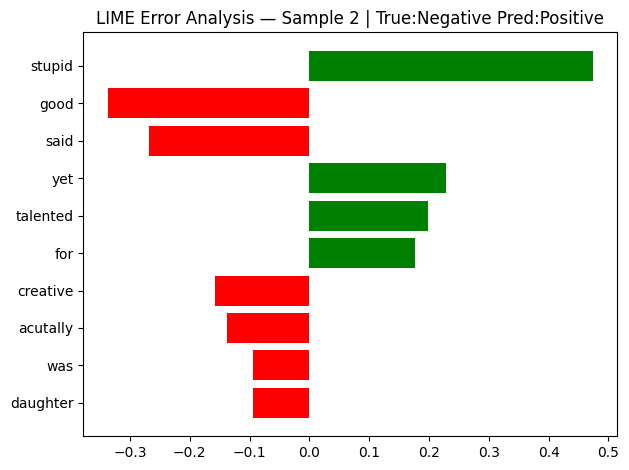


Error 3:
  True : Positive
  Pred : Negative (conf: 0.999)
  Text : bad movie but load of laughs i m sure that everyone knows about this turkey so i won t bore you with the plot if you call it one this is ed wood s so called masterpiece and that s saying something sin...


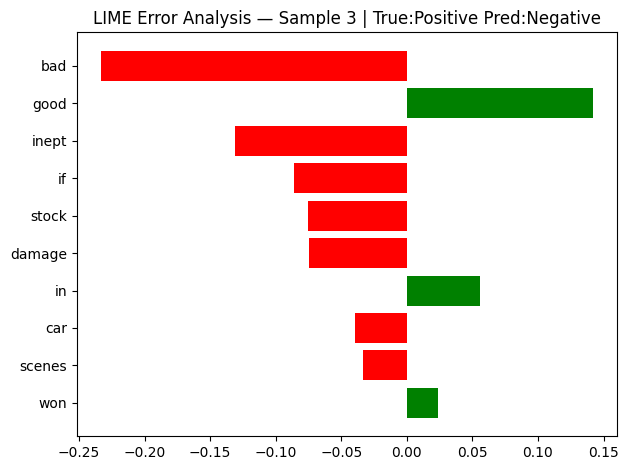


Error 4:
  True : Negative
  Pred : Positive (conf: 0.907)
  Text : are you preparing for the cissp exam on the market there are too few books which cover all the 10 common body of knowledge of the cissp exam get this book if you really need a comprehansive study guid...


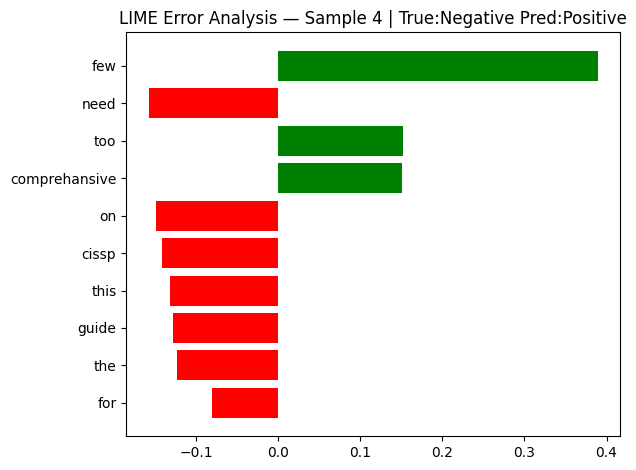


Error 5:
  True : Positive
  Pred : Negative (conf: 0.828)
  Text : difficult to write to read i can think of no other writer with the skill to take us back in time to explore the issues presented in the silent cry it is not an easy story to read but it deals with asp...


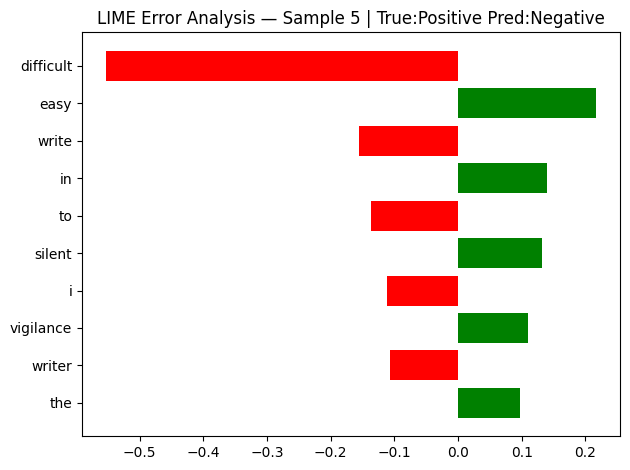

In [38]:
# Show 5 misclassified examples with LIME explanation
error_samples = errors['text'].head(5).tolist()
error_labels  = errors['label'].head(5).tolist()

print('Inspecting misclassified samples with LIME...\n')
for i, (text, true_lab) in enumerate(zip(error_samples, error_labels)):
    pred_prob = predict_proba([text])[0]
    pred_lab  = int(np.argmax(pred_prob))
    print(f'\nError {i+1}:')
    print(f'  True : {LABEL_MAP[true_lab]}')
    print(f'  Pred : {LABEL_MAP[pred_lab]} (conf: {pred_prob[pred_lab]:.3f})')
    print(f'  Text : {text[:200]}...')
    exp = lime_explain(text, num_features=10)
    fig = exp.as_pyplot_figure(label=true_lab)
    plt.title(f'LIME Error Analysis — Sample {i+1} | True:{LABEL_MAP[true_lab]} Pred:{LABEL_MAP[pred_lab]}')
    plt.tight_layout()
    plt.show()

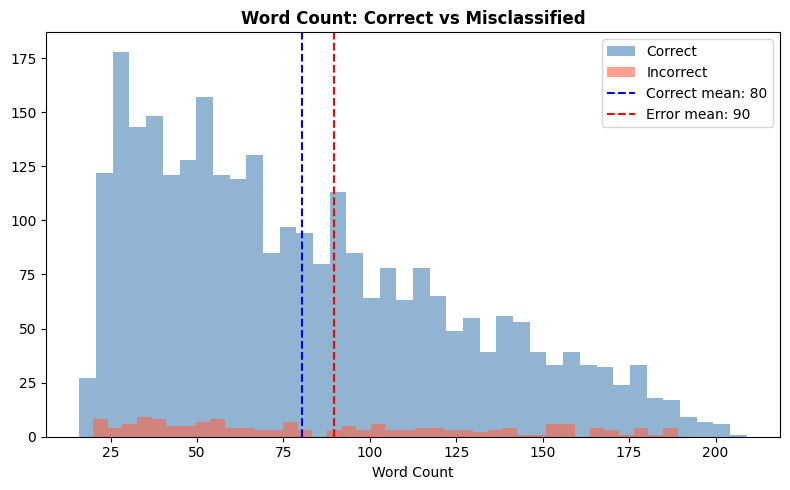

Correct   avg length: 80.4 words
Incorrect avg length: 89.6 words


In [39]:
# Text length analysis of errors
correct_df = test_df[test_df['correct']]
error_df   = test_df[~test_df['correct']]
correct_df = correct_df.copy(); error_df = error_df.copy()
correct_df['word_count'] = correct_df['text'].str.split().str.len()
error_df['word_count']   = error_df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(correct_df['word_count'], bins=40, alpha=0.6, label='Correct', color='steelblue')
ax.hist(error_df['word_count'],   bins=40, alpha=0.6, label='Incorrect', color='tomato')
ax.axvline(correct_df['word_count'].mean(), color='blue',  linestyle='--', label=f'Correct mean: {correct_df["word_count"].mean():.0f}')
ax.axvline(error_df['word_count'].mean(),   color='red',   linestyle='--', label=f'Error mean: {error_df["word_count"].mean():.0f}')
ax.set_title('Word Count: Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Word Count'); ax.legend()
plt.tight_layout()
plt.show()

print(f'Correct   avg length: {correct_df["word_count"].mean():.1f} words')
print(f'Incorrect avg length: {error_df["word_count"].mean():.1f} words')

In [40]:
print('\n' + '='*60)
print('  ALL OUTPUTS SAVED TO plots/ AND data/')
print('='*60)
import glob
for f in sorted(glob.glob('plots/*.png')):
    print(f'  {f}')
print('\nAssignment 4 notebook complete!')


  ALL OUTPUTS SAVED TO plots/ AND data/

Assignment 4 notebook complete!
